# 07 Image Processing and Feature Extraction

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Load a real photograph and inspect its shape, dtype and pixel range
- Resize, normalize, and convert color (e.g. grayscale) as preprocessing steps
- Apply a simple feature extraction step (Sobel edge detection) and compare with the original
- See why these tools need real structure: the same filter on a noise-corrupted image returns a stronger but meaningless response
- Visualize original vs processed image with clear axis labels

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 3, lesson 05 "Representing Images as Vectors and Computing Angles and Distances" — an image as an array of numbers; here we transform that array before a model sees it.

**Used later in:** Course 10 (AIAT 124) — Unit 3 — image generation works on exactly these arrays.

---

## 🌍 Real life

**Where is this used?** Image processing and feature extraction are used in **medical imaging**, **autonomous driving** (lane/object edges), and **document scanning** (e.g. receipt digitization). Before feeding images into a CNN, we usually resize, normalize, and sometimes extract hand-crafted features for analysis.

**In this notebook we use** basic **image processing** (resize, normalize, grayscale) and **edge detection** to **prepare and understand image data**. We use **filters and feature extraction** (instead of raw pixels only) **because** edges and structure help both classical computer vision and deep learning; CNNs later learn similar filters automatically.

**📌 Covers slide(s):** **10** — Image Processing Basics (pixels, RGB/grayscale, augmentation). *Do this notebook after that slide; bridges to Unit 2 CNNs.*

---

**Before starting:** Run the imports cell below. Requires OpenCV (`cv2`) and scikit-learn — the photograph we use ships inside scikit-learn, so nothing is downloaded.


## Theory (short)

- **Image** = 2D (grayscale) or 3D (e.g. RGB) array of numbers (pixels). Values often 0–255; models usually expect normalized (e.g. 0–1).
- **Preprocessing:** Resize to fixed size (e.g. for a model), normalize (divide by 255 or standardize), optionally convert to grayscale to reduce channels.
- **Feature extraction:** Edges (Sobel, Canny), textures, histograms. We use edges here as a simple example; CNNs learn their own features from data.
- **Pipeline:** Load image → resize → normalize → (optional) grayscale → optional hand-crafted features → feed to model or visualize.
- **Why the image must be real:** every one of these tools looks for *structure* — an edge is a place where the image changes in an organised way, a histogram is the story of which brightnesses the scene actually contains. Run them on random pixels and you get a strong-looking answer that means nothing. We prove that at the end of Step 4.

---

## 📥 Inputs & 📤 Outputs

**Inputs:** NumPy, Matplotlib, OpenCV (`cv2`), scikit-learn (only to fetch the image).

**Dataset (real):** `china.jpg` — a real 427×640 RGB photograph of the Summer Palace pavilion in Beijing (CC-BY, Daniel Buechele), shipped *inside* scikit-learn as a sample image, so it loads offline with no download. The worked example at the end uses the real **California Housing** dataset.

**Outputs:** Printed image shape, dtype and pixel range at each stage; a 2×3 figure showing the original photo, its grayscale/resized/normalized version, its Sobel edge map, its intensity histogram, and — as a controlled comparison — the same photo with heavy noise added and the edge map that noise destroys.

In [1]:
# Step 1: Imports
import numpy as np
import matplotlib.pyplot as plt
# OpenCV (cv2) provides fast, battle-tested image operations: resize, filters, color conversions.
import cv2
# scikit-learn ships two real photographs inside the library, so we need no download and no image file.
from sklearn.datasets import load_sample_image

print("✅ NumPy, Matplotlib, OpenCV ready.")

✅ NumPy, Matplotlib, OpenCV ready.


## Step 2: Load a real photograph (ships with scikit-learn — no download)

We use a real photo on purpose. Filters, edge maps and histograms only make sense on an image that
contains real structure: roof lines, railings, tree texture, a flat sky. On random pixels they still
produce a picture, but that picture carries no information about anything.

In [2]:
# WHAT: load a real 427x640 RGB photograph that is bundled inside scikit-learn.
# WHY: no download, works offline, and every later step has genuine structure to find.
img_rgb = load_sample_image("china.jpg")   # a photo of the Summer Palace pavilion, Beijing

print("Image shape:", img_rgb.shape, "(height, width, colour channels)")
print("dtype:", img_rgb.dtype, "| pixel range:", img_rgb.min(), "-", img_rgb.max())
print("Channel means — R: %.1f  G: %.1f  B: %.1f" % (
    img_rgb[:, :, 0].mean(), img_rgb[:, :, 1].mean(), img_rgb[:, :, 2].mean()))
print("Memory for this one image: %.2f MB" % (img_rgb.nbytes / 1e6))

Image shape: (427, 640, 3) (height, width, colour channels)
dtype: uint8 | pixel range: 0 - 255
Channel means — R: 144.7  G: 145.5  B: 140.9
Memory for this one image: 0.82 MB


## Step 3: Grayscale, resize and normalize (typical preprocessing for deep learning)

In [3]:
# WHAT: three standard preprocessing steps — colour -> gray, resize to a fixed square, scale to 0-1.
# WHY: a CNN expects a fixed input size, and 0-1 inputs keep training stable.
# Grayscale drops 3 channels to 1: cheaper, and edges live in brightness, not colour.
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# INTER_AREA averages the pixels it discards, so shrinking does not invent jagged fake edges.
# Note: forcing 640x427 into a square DOES squash the picture — real pipelines either squash or crop.
img_resized = cv2.resize(img_gray, (128, 128), interpolation=cv2.INTER_AREA)

# Dividing by 255 rescales pixels from 0-255 down to 0-1.
img_normalized = img_resized.astype(np.float32) / 255.0

print("Grayscale shape:", img_gray.shape, "(3 channels -> 1)")
print("Resized shape  :", img_resized.shape)
print("Normalized range: %.2f - %.2f  (mean %.2f)" % (
    img_normalized.min(), img_normalized.max(), img_normalized.mean()))

Grayscale shape: (427, 640) (3 channels -> 1)
Resized shape  : (128, 128)
Normalized range: 0.00 - 1.00  (mean 0.57)


## Step 4: Edge detection (we use Sobel instead of raw pixels to highlight structure)

In [4]:
# We use Sobel to extract edges; CNNs later learn similar filters from data.
# Two Sobel passes: one responds to vertical edges (x), the other to horizontal edges (y).
def sobel_magnitude(gray_img):
    sx = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)   # change across the width
    sy = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)   # change down the height
    # Combine both directions into a single edge-strength map (the gradient magnitude).
    return np.sqrt(sx**2 + sy**2)

edges = sobel_magnitude(img_resized)
print("Edge map shape:", edges.shape)
print("Edge strength — mean %.1f, max %.1f, %.0f%% of pixels above 100" % (
    edges.mean(), edges.max(), 100 * (edges > 100).mean()))

# ── Controlled comparison: what happens when the structure is buried in noise ───────────────
# We add Gaussian noise TO THE REAL PHOTO (this is the one place randomness belongs here:
# the noise is the thing being demonstrated, not the data).
rng = np.random.default_rng(0)
img_noisy = np.clip(img_resized.astype(np.float32) + rng.normal(0, 40, img_resized.shape),
                    0, 255).astype(np.uint8)
edges_noisy = sobel_magnitude(img_noisy)

print("\nSame Sobel filter, same scene, after adding noise (sigma=40):")
print("  clean photo : mean |gradient| %.1f, %.0f%% of pixels above 100" % (
    edges.mean(), 100 * (edges > 100).mean()))
print("  noisy photo : mean |gradient| %.1f, %.0f%% of pixels above 100" % (
    edges_noisy.mean(), 100 * (edges_noisy > 100).mean()))
print("  correlation between the two edge maps: %.2f" % np.corrcoef(edges.ravel(), edges_noisy.ravel())[0, 1])
print("A stronger response is NOT a better one: noise fires the filter everywhere,")
print("so the edge map stops separating the building from the sky. Denoise before you detect.")

Edge map shape: (128, 128)
Edge strength — mean 80.8, max 792.2, 29% of pixels above 100

Same Sobel filter, same scene, after adding noise (sigma=40):
  clean photo : mean |gradient| 80.8, 29% of pixels above 100
  noisy photo : mean |gradient| 179.7, 73% of pixels above 100
  correlation between the two edge maps: 0.62
A stronger response is NOT a better one: noise fires the filter everywhere,
so the edge map stops separating the building from the sky. Denoise before you detect.


## Step 5: Visualize the pipeline — and the failure case

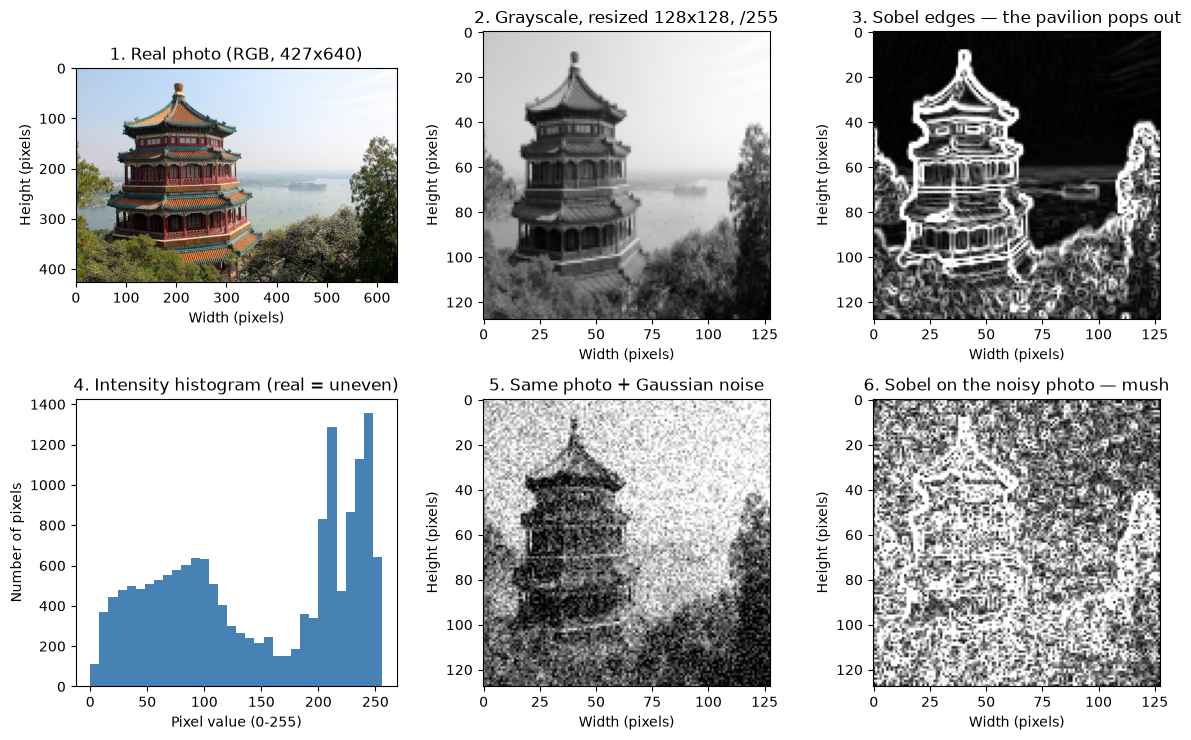

✅ Pipeline plotted: real image -> preprocessing -> features, plus the noisy control.


In [5]:
# WHAT: show every stage side by side: real photo, preprocessed, edges, histogram, noisy, noisy edges.
# WHY: seeing input vs extracted feature makes 'feature extraction' concrete - edges are what the filter kept,
#      and the bottom row shows what the same filter returns when the structure is drowned in noise.
fig, ax = plt.subplots(2, 3, figsize=(12, 7.5))

ax[0, 0].imshow(img_rgb)
ax[0, 0].set_title("1. Real photo (RGB, 427x640)")
ax[0, 1].imshow(img_normalized, cmap="gray")
ax[0, 1].set_title("2. Grayscale, resized 128x128, /255")
ax[0, 2].imshow(np.clip(edges, 0, 255), cmap="gray")
ax[0, 2].set_title("3. Sobel edges — the pavilion pops out")

# A real scene has a lop-sided histogram: dark trees, mid-tone building, a bright sky spike.
ax[1, 0].hist(img_resized.ravel(), bins=32, range=(0, 256), color="steelblue")
ax[1, 0].set_title("4. Intensity histogram (real = uneven)")
ax[1, 0].set_xlabel("Pixel value (0-255)")
ax[1, 0].set_ylabel("Number of pixels")

ax[1, 1].imshow(img_noisy, cmap="gray")
ax[1, 1].set_title("5. Same photo + Gaussian noise")
ax[1, 2].imshow(np.clip(edges_noisy, 0, 255), cmap="gray")
ax[1, 2].set_title("6. Sobel on the noisy photo — mush")

for a in [ax[0, 0], ax[0, 1], ax[0, 2], ax[1, 1], ax[1, 2]]:
    a.set_xlabel("Width (pixels)")
    a.set_ylabel("Height (pixels)")

plt.tight_layout()
plt.show()
print("✅ Pipeline plotted: real image -> preprocessing -> features, plus the noisy control.")

## 🌍 Real-World Worked Example — House Prices (Manual Backprop on Real Data)

**Why a price model in an image notebook?** Because the filters you just applied by hand are exactly
what a CNN learns by itself — and it learns them with the backpropagation below. Same engine, tabular
data here so every derivative stays visible (this is the manual version of notebook `05`).

We train a 1-hidden-layer network **with manual backpropagation** on the **California Housing** dataset
(20,640 block groups from the 1990 US Census, bundled with scikit-learn), predicting the **median house
value of a block group** from its **median income**.

**Read the result honestly:** one real feature does not explain real prices, and the flat line of points
at $500,001 is the Census cap, not a market effect.

Real dataset: California Housing — 1000 of 20640 block groups (random_state=42)
Feature: MedInc, range 0.68-15.00 ($10k)
Target : median house value, range 0.30-5.00 ($100k)
Values capped at $500,001 by the Census: 4.8% of this sample

MSE (standardised): 1.0257 -> 0.5194 after 500 epochs
R² on real prices : 0.481  (a plain straight line gets 0.474)
Typical error     : $83,873 per block group


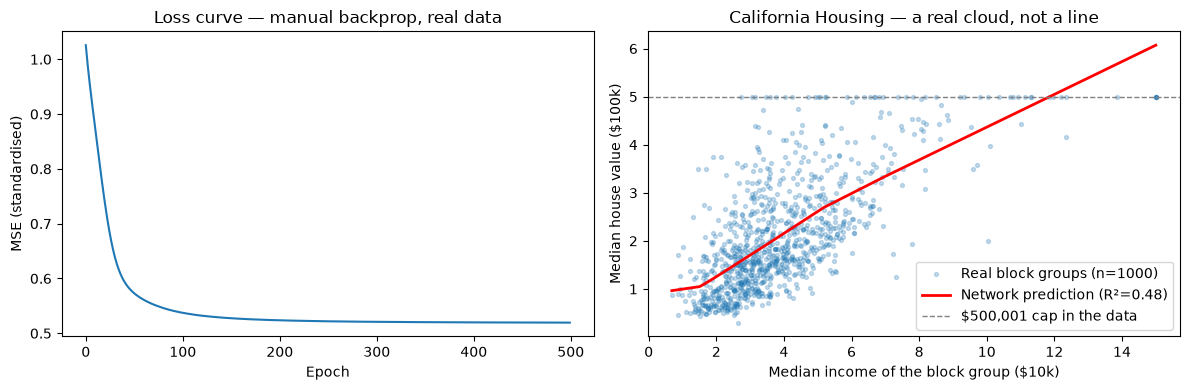

In [6]:
# WHAT: manual backpropagation (chain rule by hand) on a REAL regression dataset.
# WHY: this is the update rule a CNN uses too — here it is small enough to read line by line.
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression

# ── Real data: California Housing (1990 US Census), bundled with scikit-learn ───────────────
housing = fetch_california_housing()
sampler = np.random.RandomState(42)                    # sampling only — the DATA is real
idx = sampler.choice(len(housing.data), size=1000, replace=False)
X = housing.data[idx][:, [0]].astype(np.float32)       # MedInc: median income, in $10,000s
y = housing.target[idx].reshape(-1, 1).astype(np.float32)  # median house value, in $100,000s

print(f"Real dataset: California Housing — {len(X)} of {len(housing.data)} block groups (random_state=42)")
print(f"Feature: MedInc, range {X.min():.2f}-{X.max():.2f} ($10k)")
print(f"Target : median house value, range {y.min():.2f}-{y.max():.2f} ($100k)")
print(f"Values capped at $500,001 by the Census: {(y >= 5.0).mean()*100:.1f}% of this sample")

# Standardise both (gradient descent behaves badly on raw scales).
X_n = (X - X.mean()) / X.std()
y_n = (y - y.mean()) / y.std()

# ── Manual 1-hidden-layer network ──────────────────────────────────────────────────────────
def relu(z): return np.maximum(0, z)
def relu_d(z): return (z > 0).astype(float)

init = np.random.RandomState(0)          # random WEIGHT INIT — this randomness is the lesson
W1 = init.randn(1, 16) * 0.1;  b1 = np.zeros((1, 16))
W2 = init.randn(16, 1) * 0.1;  b2 = np.zeros((1, 1))
lr = 0.05;  losses = [];  n = len(X_n)

for _ in range(500):
    # Forward
    z1 = X_n @ W1 + b1          # (n, 16)
    a1 = relu(z1)
    z2 = a1 @ W2 + b2            # (n, 1)
    loss = ((z2 - y_n)**2).mean()
    losses.append(loss)

    # ── Backpropagation (chain rule, step by step) ─────────────────────────
    dL_dz2 = 2*(z2 - y_n) / n
    dL_dW2 = a1.T @ dL_dz2
    dL_db2 = dL_dz2.sum(0, keepdims=True)
    dL_da1 = dL_dz2 @ W2.T
    dL_dz1 = dL_da1 * relu_d(z1)
    dL_dW1 = X_n.T @ dL_dz1
    dL_db1 = dL_dz1.sum(0, keepdims=True)

    # Gradient descent step
    W2 -= lr * dL_dW2;  b2 -= lr * dL_db2
    W1 -= lr * dL_dW1;  b1 -= lr * dL_db1

# ── Score it on the real price scale, and against a plain straight line ────────────────────
pred = (relu(X_n @ W1 + b1) @ W2 + b2) * y.std() + y.mean()
r2   = 1 - ((pred - y)**2).sum() / ((y - y.mean())**2).sum()
rmse = float(np.sqrt(((pred - y)**2).mean()))
ols_r2 = LinearRegression().fit(X, y).score(X, y)     # honest baseline: one straight line

print(f"\nMSE (standardised): {losses[0]:.4f} -> {losses[-1]:.4f} after 500 epochs")
print(f"R² on real prices : {r2:.3f}  (a plain straight line gets {ols_r2:.3f})")
print(f"Typical error     : ${rmse*100_000:,.0f} per block group")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(losses); plt.title("Loss curve — manual backprop, real data")
plt.xlabel("Epoch"); plt.ylabel("MSE (standardised)")
plt.subplot(1, 2, 2)
order = X[:, 0].argsort()
plt.scatter(X, y, s=8, alpha=0.25, label=f"Real block groups (n={len(X)})")
plt.plot(X[order], pred[order], 'r-', lw=2, label=f"Network prediction (R²={r2:.2f})")
plt.axhline(5.0, ls='--', c='gray', lw=1, label="$500,001 cap in the data")
plt.xlabel("Median income of the block group ($10k)"); plt.ylabel("Median house value ($100k)")
plt.legend(); plt.title("California Housing — a real cloud, not a line")
plt.tight_layout(); plt.show()

## 🧩 Mini-exercise

**Try it:** In a new code cell, cut a 3×3 patch out of the real grayscale image (`img_resized[60:63, 60:63]`) and print it — those nine numbers are all a 3×3 filter ever sees at one position. Normalize the patch to [0,1] and print its min/max and shape. Then resize the whole image to 28×28 (the MNIST size) with `cv2.resize(..., interpolation=cv2.INTER_AREA)`, re-run `sobel_magnitude` on it, and compare: at 28×28, can you still tell the pavilion from the trees?

**Then:** swap `"china.jpg"` for `"flower.jpg"` (the other photo bundled with scikit-learn) and re-run Steps 2–5. Which image gives the stronger mean edge response, and does that make it the "better" image?

---

## ✅ Summary

**What you did:**
- Loaded a **real 427×640 RGB photograph** (bundled with scikit-learn, no download) and inspected its shape, dtype and channel means.
- Converted it to grayscale, resized it to 128×128 with `INTER_AREA`, and normalized to 0–1 — the standard pre-CNN pipeline.
- Applied Sobel edge detection: **mean |gradient| 80.8**, with **29% of pixels above 100** — and the pavilion's roof lines are clearly visible in the edge map, while the sky stays black because nothing changes there.
- Ran a controlled failure case: adding Gaussian noise (σ=40) to that same photo pushed the mean edge response *up* to **179.7** with **73% of pixels above 100**, and the correlation between the clean and noisy edge maps fell to **0.62**.

**The honest lesson from that comparison:** a bigger filter response is not a better one. Noise makes every pixel look like an edge, so the edge map stops distinguishing anything — which is exactly why running these tools on a random-pixel image (as this notebook used to) produces confident-looking output that carries no information. Real structure first, filters second.

**In real life you'd also:** load images from disk or a dataset loader, denoise or blur before detecting edges, use data augmentation, and feed normalized batches into a CNN.

**The main idea:** Preprocessing (grayscale, resize, normalize) and optional feature extraction (e.g. edges) prepare images for models; CNNs later learn their own filters from data — trained by the same backpropagation shown in the worked example above.

**Next:** Unit 2 CNNs use convolutional layers that learn similar edge-like and texture features automatically.

## 📚 References

1. LeCun, Y., Bottou, L., Bengio, Y. & Haffner, P. (1998). *Gradient-Based Learning Applied to Document Recognition*. Proceedings of the IEEE 86(11), 2278-2324.
2. Krizhevsky, A., Sutskever, I. & Hinton, G. E. (2012). *ImageNet Classification with Deep Convolutional Neural Networks*. NeurIPS. https://papers.nips.cc/paper_files/paper/2012/hash/c399862d3b9d6b76c8436e924a68c45b-Abstract.html
3. Dosovitskiy, A. et al. (2021). *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale* (ViT). ICLR. https://arxiv.org/abs/2010.11929

**Data used in this notebook**

4. `china.jpg` — photograph by Daniel Buechele, Creative Commons BY 2.0, retrieved 2011 by Robert Layton and distributed with scikit-learn as a sample image (`load_sample_image`). https://creativecommons.org/licenses/by/2.0/
5. Pace, R. K. & Barry, R. (1997). *Sparse spatial autoregressions*. Statistics & Probability Letters 33(3), 291-297. https://doi.org/10.1016/S0167-7152(96)00140-X (the California Housing data, from the 1990 US Census; `fetch_california_housing`)

**Recent work (2024–2026)**

6. Siméoni, O. et al. (2025). *DINOv3*. arXiv. https://arxiv.org/abs/2508.10104 — the 2026 default answer to "give me features for this image": a self-supervised vision backbone reported to beat specialised systems across a broad range of settings *without fine-tuning*.
7. Bai et al. (2025). *Qwen2.5-VL Technical Report*. arXiv. https://arxiv.org/abs/2502.13923 — handles native and dynamic input resolution, so the hand-tuned resize/crop decisions in this notebook matter less than they used to.
